<a href="https://colab.research.google.com/github/OlhaZahrebelna/Intelligent-Support-Ticket-Router-using-NLP/blob/main/Intelligent_Support_Ticket_Router_Description_and_EDA_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Intelligent Support Ticket Router

## Project Overview

Customer support teams receive thousands of requests every day through emails, web forms, and chat platforms. Manually reviewing and routing each ticket is time-consuming and may delay response times.

The objective of this project is to develop an **Intelligent Support Ticket Router** that automatically classifies incoming customer messages into the appropriate support category using Natural Language Processing (NLP) and Machine Learning.

The project will be developed incrementally, starting with classical machine learning models and progressing toward transformer-based models and Retrieval-Augmented Generation (RAG).

---

## Business Objective

Automatically assign each customer support ticket to the correct department, reducing manual effort and improving response efficiency.

### Example

**Input**

> "I was charged twice for my monthly subscription."

**Predicted Category**

> Billing

---

## Project Workflow

```text
Customer Message
        │
        ▼
Data Cleaning & Preprocessing
        │
        ▼
Feature Extraction
(TF-IDF / BERT Embeddings)
        │
        ▼
Text Classification Model
        │
        ▼
Predicted Category
        │
        ▼
Support Team Routing
```

---

## Dataset

This project uses the **Customer Support Tickets** dataset from Hugging Face, containing over **61,000** customer support requests.

The dataset includes:

* Ticket subject
* Ticket description
* Ticket type
* Ticket priority
* Customer support response
* Additional metadata

These data simulate real-world customer support interactions and provide an excellent benchmark for text classification tasks.

---

## Notebook Objectives

In this notebook, we will:

* Load the dataset
* Explore its structure
* Inspect feature types
* Check for missing values
* Analyze ticket categories
* Explore text length distributions
* Identify potential preprocessing requirements

The insights obtained during this exploratory analysis will guide feature engineering and model development in the following notebooks.



### Load data

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from datasets import load_dataset

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
print(dataset)

print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})
{'subject': 'Wesentlicher Sicherheitsvorfall', 'body': 'Sehr geehrtes Support-Team,\\n\\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\\n\\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnt

#### Convert the training split into a pandas DataFrame for analysis

In [4]:
df = dataset["train"].to_pandas()

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


###EDA аналіз

#### Check the number of rows and columns in the dataset

In [5]:
df.shape

(61765, 16)

#### Display information about columns, data types, and missing values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  object 
 1   body      61763 non-null  object 
 2   answer    48576 non-null  object 
 3   type      48587 non-null  object 
 4   queue     61765 non-null  object 
 5   priority  61765 non-null  object 
 6   language  61765 non-null  object 
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  object 
 9   tag_2     48528 non-null  object 
 10  tag_3     48356 non-null  object 
 11  tag_4     43990 non-null  object 
 12  tag_5     27636 non-null  object 
 13  tag_6     13225 non-null  object 
 14  tag_7     5968 non-null   object 
 15  tag_8     2472 non-null   object 
dtypes: float64(1), object(15)
memory usage: 7.5+ MB


#### List all available columns

In [7]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='object')

#### Count missing values in each column

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
tag_8,59293
tag_7,55797
tag_6,48540
tag_5,34129
version,33178
tag_4,17775
tag_3,13409
tag_2,13237
answer,13189
type,13178


#### Check the number of unique values in every column

In [9]:
for col in df.columns:
    print(col, df[col].nunique())

subject 46635
body 53364
answer 40139
type 4
queue 52
priority 5
language 2
version 3
tag_1 211
tag_2 350
tag_3 591
tag_4 831
tag_5 956
tag_6 920
tag_7 755
tag_8 512


#### Define the target variable and inspect class frequencies

In [10]:
target_col = "queue"

df[target_col].value_counts()

,count
queue,
Technical Support,14186
Product Support,8960
Customer Service,7420
IT Support,5725
Billing and Payments,4874
Returns and Exchanges,2438
Service Outages and Maintenance,1912
Sales and Pre-Sales,1490
Human Resources,914


#### Visualize the 10 most common ticket categories

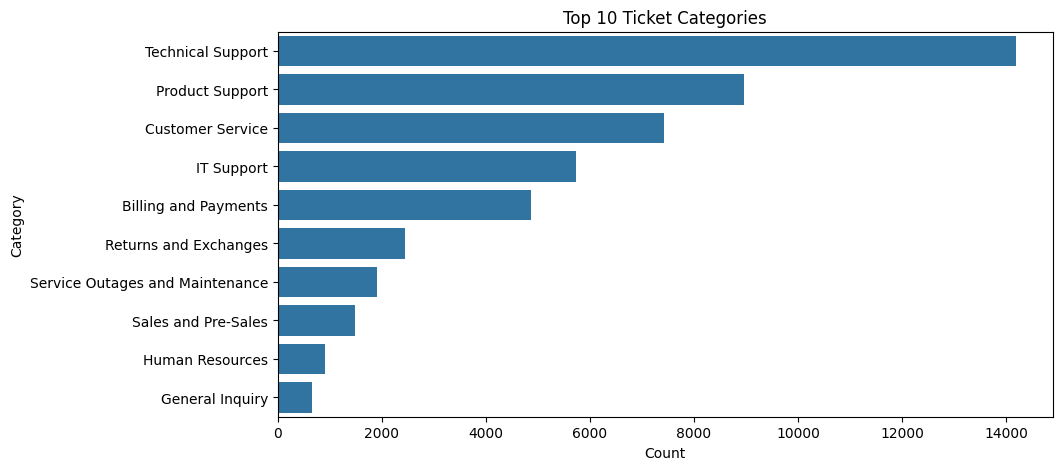

In [11]:
top10 = df[target_col].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y=target_col,
    order=top10
)

plt.title("Top 10 Ticket Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

In [12]:
df[['tag_1','tag_2','tag_3','tag_4','tag_5','tag_6','tag_7','tag_8']].isnull().sum()

,0
tag_1,13178
tag_2,13237
tag_3,13409
tag_4,17775
tag_5,34129
tag_6,48540
tag_7,55797
tag_8,59293


#### Frequency of Primary Tags

In [13]:
df['tag_1'].value_counts().head(10)

,count
tag_1,
Security,9156
Bug,7665
Feedback,5409
Technical,5034
Feature,4424
Performance,3865
Billing,2485
Outage,1755
Network,1482


The tag analysis showed that each support ticket can contain between one and eight thematic tags. The most frequent tags are Security, Bug, Feedback, Technical, and Feature, indicating that the majority of customer requests are related to security issues, software bugs, technical support, and system features. Missing values in the tag_1–tag_8 columns do not represent data quality issues; rather, they indicate that no additional tags were assigned to those particular tickets.

#### Inspect language distribution

In [14]:
df["language"].value_counts()

,count
language,
de,33504
en,28261


#### Plot the language distribution

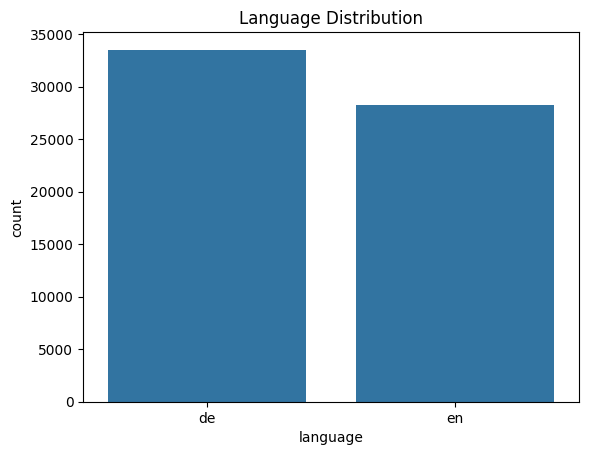

In [15]:
sns.countplot(data=df, x="language")
plt.title("Language Distribution")
plt.show()

#### Keep only English-language tickets for further analysis

In [16]:
df_en = df[df["language"].str.lower() == "en"].copy()
df_en.shape

(28261, 16)

#### Create text-length features for exploratory analysis

In [17]:
df_en["subject_len"] = df_en["subject"].astype(str).apply(len)
df_en["body_len"] = df_en["body"].astype(str).apply(len)
df_en["body_words"] = df_en["body"].astype(str).apply(lambda x: len(x.split()))

#### Generate descriptive statistics for the new text-length features

In [18]:
df_en[["subject_len", "body_len", "body_words"]].describe()

,subject_len,body_len,body_words
count,28261.000000,28261.000000,28261.000000
mean,38.554970,371.265843,55.352677
std,19.780095,202.882721,31.249665
min,3.000000,4.000000,1.000000
25%,28.000000,203.000000,30.000000
50%,39.000000,365.000000,54.000000
75%,50.000000,533.000000,79.000000
max,258.000000,1793.000000,272.000000


#### Visualize the distribution of ticket body lengths

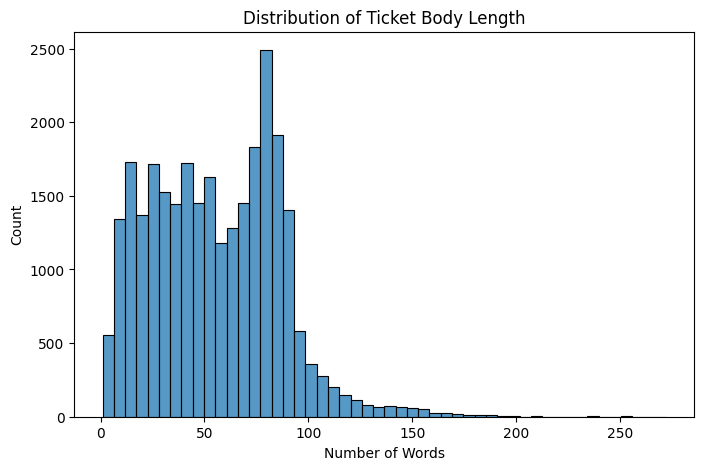

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df_en["body_words"], bins=50)
plt.title("Distribution of Ticket Body Length")
plt.xlabel("Number of Words")
plt.show()

#### Display a random sample of processed tickets

In [20]:
df_en[["subject", "body", target_col]].sample(10, random_state=42)

,subject,body,queue
18558,None,Please request an update to the integration se...,Product Support
49912,Data Breach Happened Because of Lack of Encryp...,Insufficient encryption led to the data breach...,Technical Support
17224,Query Concerning Decline in Website Traffic,The analytics data for the website have indica...,Customer Service
14259,None,I am currently encountering integration proble...,Technical Support
23951,Optimization of Investments Using Alteryx,"Hello Customer Support, I am interested in und...",Customer Service
43370,Support for Integrating BigCommerce with ClickUp,Can you offer comprehensive instructions for i...,IT Support
44578,Request for Information on Investment Optimiza...,Could you provide details on the investment op...,Returns and Exchanges
10967,Enhance Investment Analysis Tools,"Customer Support, reaching out for the optimiz...",Returns and Exchanges
52167,Recent Slowdown in Marketing Activities,Our digital marketing initiatives have plateau...,Product Support
52482,Crash of the data analytics dashboard followin...,The data analytics dashboard abruptly stopped ...,Technical Support


#### Calculate percentage distribution of target classes

In [21]:
class_dist = df_en[target_col].value_counts(normalize=True) * 100
class_dist

,proportion
queue,
Technical Support,28.834790
Product Support,18.771452
Customer Service,15.105623
IT Support,11.793638
Billing and Payments,10.250876
Returns and Exchanges,4.960900
Service Outages and Maintenance,3.913520
Sales and Pre-Sales,2.982909
Human Resources,1.956760


#### Visualize class distribution as percentages

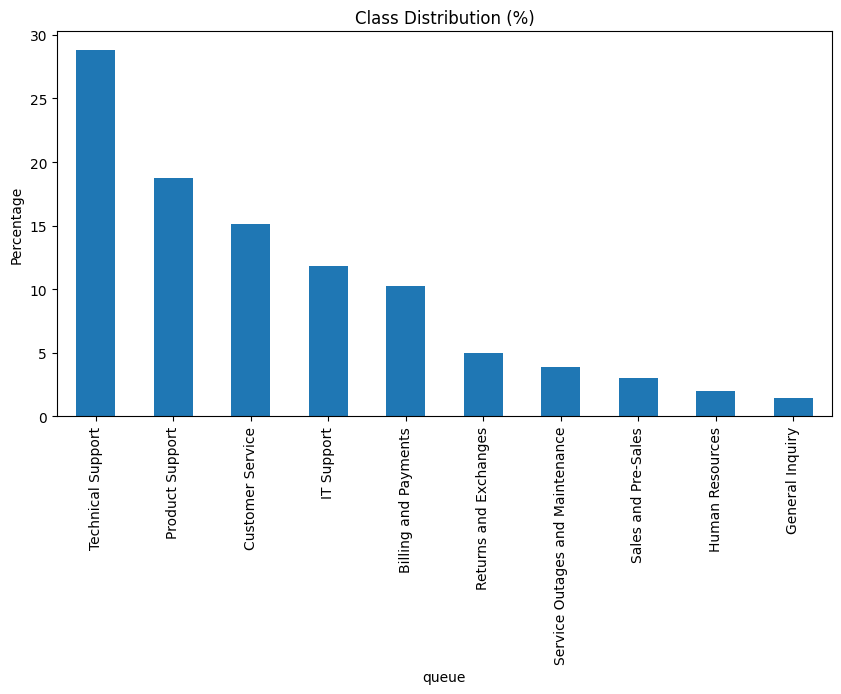

In [22]:
plt.figure(figsize=(10, 5))
class_dist.plot(kind="bar")
plt.title("Class Distribution (%)")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.show()

#### Merge subject and body into a single text feature for NLP tasks

In [23]:
df_en["text"] = (
    df_en["subject"].fillna("") + " " + df_en["body"].fillna("")
)

df_en[["text", target_col]].head()

,text,queue
1,"Account Disruption Dear Customer Support Team,...",Technical Support
2,Query About Smart Home System Integration Feat...,Returns and Exchanges
3,Inquiry Regarding Invoice Details Dear Custome...,Billing and Payments
4,Question About Marketing Agency Software Compa...,Sales and Pre-Sales
5,"Feature Query Dear Customer Support,\n\nI hope...",Technical Support


#### Save the cleaned dataset for the next stages of the project

In [24]:
eda_df = df_en[["text", "subject", "body", target_col, "priority", "type", "language"]].copy()

eda_df.to_csv("customer_support_tickets_cleaned.csv", index=False)

#Final Conclusion of the Exploratory Data Analysis (EDA)

The exploratory data analysis shows that the support ticket dataset is well-suited for developing an intelligent ticket routing model. After data cleaning and preprocessing, the dataset was filtered to 28,261 English-language tickets, ensuring consistency for NLP-based classification.

Key findings from the analysis include:

* The dataset contains meaningful textual information, with ticket bodies averaging 371 characters (approximately 55 words) and subjects averaging 39 characters, providing sufficient context for automated classification.
* The target variable (queue) is imbalanced, with Technical Support (28.8%), Product Support (18.8%), Customer Service (15.1%), IT Support (11.8%), and Billing and Payments (10.3%) accounting for most tickets, while several categories have relatively few examples. This imbalance should be considered during model training using techniques such as class weighting or resampling.
* Ticket text was prepared for downstream NLP tasks by merging the subject and body into a single text feature, enabling the model to utilize complete ticket context.
* Exploratory statistics indicate a wide variation in ticket length, suggesting that the model should be capable of handling both short and detailed customer requests.


Overall, the EDA confirms that the dataset is clean, informative, and appropriate for building a machine learning model for automatic support ticket routing. The primary challenge identified is the class imbalance, while the rich textual content provides a strong foundation for training transformer-based models such as BERT or DistilBERT to accurately classify tickets into their respective support queues.